In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from joblib import dump, load
from collections import Counter
import warnings

# Métricas e ferramentas de Machine Learning
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, cross_validate
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
from cuml.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import shap

dados = pd.read_csv ("../Databases/base_treino_boruta.csv", sep=',')
dados

ModuleNotFoundError: No module named 'cuml'

In [ ]:
# normalizar
# remover colunas que não são features
dados_num = dados.drop(columns=["sample_id", "target", "split"])

# target (0/1) separado como categorico
dados_cat = dados[["target"]]

# Instanciar o objeto normalizador
normalizador = preprocessing.MinMaxScaler()

# treinar o normalizador apenas nas features
modelo_normalizador_num = normalizador.fit(dados_num)

# salvando modelo normalizador
dump(modelo_normalizador_num, open("models_Tree_XGBoost/normalizador_TCC_Tree_XGBoost.model","wb"))

# normalizar atributos numéricos
dados_num_normalizado = modelo_normalizador_num.transform(dados_num)

# converter de volta para DataFrame
dados_num_df = pd.DataFrame(dados_num_normalizado, columns=dados_num.columns)

# juntar target (0/1) e split
dados_final = dados_num_df.join(dados_cat).join(dados[["split"]])
dados_final

,MIMAT0000062_st,MIMAT0000063_st,MIMAT0000064_st,MIMAT0000065_st,MIMAT0000066_st,MIMAT0000067_st,MIMAT0000068_st,MIMAT0000069_st,MIMAT0000070_st,MIMAT0000071_st,...,MIMAT0031175_st,MIMAT0031176_st,MIMAT0031177_st,MIMAT0031178_st,MIMAT0031179_st,MIMAT0031180_st,MIMAT0031181_st,Grupo_Controle,Grupo_PDAC,Grupo_nan
0,0.364020,0.616390,0.295100,0.357728,0.346143,0.246612,0.281153,0.791741,0.567829,0.293147,...,0.318945,0.485705,0.572516,0.820679,0.450881,0.418451,0.829685,0,1,0
1,0.566594,0.930115,0.621546,0.339320,0.389451,0.274622,0.596963,0.371203,0.940650,0.244754,...,0.753015,0.430443,0.524971,0.710573,0.730846,0.132892,0.395607,0,1,0
2,0.413573,0.686656,0.610854,0.334182,0.424265,0.288782,0.131408,0.729368,0.610426,0.575846,...,0.810807,0.150539,0.355937,0.197553,0.229818,0.473060,0.694120,0,1,0
3,0.398440,0.588351,0.496557,0.319919,0.458100,0.148070,0.250906,0.534658,0.831239,0.250591,...,0.751642,0.193662,0.103271,0.298098,0.341681,0.509392,0.780955,0,1,0
4,0.522772,0.604046,0.533159,0.425419,0.313721,0.121369,0.160196,0.428900,1.000000,0.237128,...,0.492416,0.259330,0.482838,0.881627,0.576288,0.418772,0.629635,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,0.344610,0.745889,0.686059,0.269489,0.640015,0.243700,0.198017,0.646852,0.622801,0.311664,...,0.442040,0.305828,0.447887,0.140583,0.208489,0.365372,0.216334,1,0,0
103,0.553144,0.715492,0.557298,0.484770,0.575855,0.301305,0.426057,0.414091,0.457515,0.127880,...,0.873334,0.274848,0.130887,0.582882,0.737640,0.353141,0.543719,1,0,0
104,0.491946,0.691766,0.438745,0.402720,0.294213,0.310961,0.149621,0.656055,0.669959,0.330950,...,0.201646,0.228655,0.517757,0.196500,0.640867,0.584396,0.856907,1,0,0
105,0.180837,0.730245,0.640391,0.394445,0.651872,0.190110,0.331365,0.749914,0.581655,0.119255,...,0.399272,0.039293,0.371028,0.364379,0.000000,0.616909,0.379254,1,0,0


In [ ]:
# separar target e atributos
dados_classes = dados_final[['target']]
dados_atributos = dados_final.drop(columns=['target', 'split'])

# preencher NaNs numericos com media (so um seguro)
dados_atributos = dados_atributos.fillna(dados_atributos.mean())

# converter target para array binario (0/1)
dados_classes_bin = dados_classes['target'].values

resampler = SMOTE(random_state=42)

dados_atributos_b, dados_classes_b = resampler.fit_resample(dados_atributos,dados_classes_bin)

# frequência apos balanceamento
print('------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------')
print(Counter(dados_classes_b))

#### FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ####
Counter({1: 88, 0: 88})


In [ ]:
from cuml.ensemble import RandomForestClassifier
import cupy as cp
import numpy as np
import pandas as pd
import os
from joblib import dump
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

# =========================
# CONVERSÃO PARA GPU
# =========================

X = dados_atributos_b.values
y = dados_classes_b

# =========================
# TREINO GPU RF
# =========================

print("\nTreinando RandomForest GPU...")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=16,
    n_streams=1,
    random_state=42
)

rf.fit(X, y)

# =========================
# SALVAR MODELO
# =========================

os.makedirs('models_Tree_GPU', exist_ok=True)

caminho_rf = os.path.join(
    os.getcwd(),
    'models_Tree_GPU',
    'modelo_RF_GPU.joblib'
)

dump(rf, caminho_rf)

print(f"Modelo salvo em: {caminho_rf}")

# =========================
# IMPORTÂNCIA (GPU RF)
# =========================

imp = None

for attr in (
    'feature_importances_',
    'feature_importances',
    'feature_importance'
):
    if hasattr(rf, attr):
        imp = getattr(rf, attr)
        break

imp = np.asarray(imp)

rf_importances = imp

# =========================
# PERMUTATION IMPORTANCE (TESTE REAL)
# =========================

print("Calculando permutation importance (CPU)...")

dados_teste = pd.read_csv("../Databases/base_teste_boruta.csv")

X_test = dados_teste.drop(columns=["sample_id", "target", "split"])
y_test = dados_teste["target"]

X_test = X_test.fillna(X_test.mean())

cols = dados_atributos.columns

# NÃO normaliza aqui porque GPU RF normalmente foi treinado sem scaler
# (se você normalizou no treino, aqui precisa aplicar também)

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

rf_perm = perm

# =========================
# RESULTADOS
# =========================

imp_df = pd.DataFrame({
    'feature': cols,
    'impurity_imp': rf_importances
}).sort_values('impurity_imp', ascending=False)

perm_df = pd.Series(
    rf_perm.importances_mean,
    index=cols
).sort_values(ascending=False)

print("\nTop 20 (impurity)")
print(imp_df.head(20))

print("\nTop 20 (permutation)")
print(perm_df.head(20))

print("\nTreinamento GPU finalizado")

In [ ]:
# Modelo GPU  + CPU permutation importance
warnings.filterwarnings("ignore")

rf_models = {}
rf_perm = {}

# garantir pasta de saída
os.makedirs('models_Tree_GPU', exist_ok=True)

for classe, (X, y) in dados_balanceados.items():

    print(f"\n{'='*60}")
    print(f"Treinamento GPU RandomForest para: {classe}")
    print(f"{'='*60}")

    # cuML trabalha melhor com numpy arrays
    X = X.values if hasattr(X, "values") else X
    y = y.values if hasattr(y, "values") else y

    X = X.astype(np.float32)
    y = y.astype(np.int32)

    # split treino/teste
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    # modelo GPU
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        max_features="sqrt",
        min_samples_leaf=2,
        n_bins=64,
        n_streams=1,
        random_state=42
    )

    print("Treinando modelo na GPU...")
    rf.fit(X_train, y_train)


    # DEBUG / validação
    print("Distribuição y:", np.unique(y, return_counts=True))

    train_score = rf.score(X_train, y_train)
    test_score = rf.score(X_test, y_test)

    print(f"Train score: {train_score:.4f}")
    print(f"Test score: {test_score:.4f}")

    y_pred = rf.predict(X_test)
    print("Predições:", np.unique(y_pred, return_counts=True))
    
    # armazenar modelo
    rf_models[classe] = rf

    # salvar modelo
    nome_rf = f"modelo_RF_GPU_{classe.replace(' ', '_')}.joblib"
    caminho_rf = os.path.join(
        os.getcwd(),
        'models_Tree_GPU',
        nome_rf
    )

     # DEBUG / validação

    dump(rf, caminho_rf)
    print(f"Modelo salvo em: {caminho_rf}")

    # permutation importance (CPU - abordagem mais robusta)
    print("Calculando permutation importance (CPU)...")

    perm = permutation_importance(
        rf,
        X_test,
        y_test,
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    rf_perm[classe] = perm

    # dataframe de importâncias
    cols = pd.Index(dados_processados.columns)

    perm_df = pd.Series(
        perm.importances_mean,
        index=cols
    ).sort_values(ascending=False)

    print("\nTop 20 features mais importantes:")
    print(perm_df.head(20))

print("\nTreinamento GPU finalizado com sucesso.")

DIFERENCAS GRANDES AINDA NAO SEI SE VOU SEPARA TUDOOOOOOOO
-----------------------------------------------------------

In [ ]:
# Modelo GPU + SHAP 

from cuml.ensemble import RandomForestClassifier as CuMLRF
from sklearn.ensemble import RandomForestClassifier as SkRF
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

rf_gpu_models = {}
rf_cpu_models = {}
shap_results = {}

os.makedirs('models_Tree_GPU', exist_ok=True)

for classe, (X, y) in dados_balanceados.items():

    print(f"\n{'='*60}")
    print(f"Treinamento: {classe}")

    # PREPARAÇÃO
    X = X.values if hasattr(X, "values") else X
    y = y.values if hasattr(y, "values") else y

    X = X.astype(np.float32)
    y = y.astype(np.int32)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    feature_names = dados_processados.columns

    # Parametros treino GPU

    rf_gpu = CuMLRF(
        n_estimators=300,
        max_depth=25,
        max_features="sqrt",
        min_samples_leaf=2,
        n_bins=64,
        n_streams=1,
        random_state=42
    )

    print("Treinando modelo GPU...")
    rf_gpu.fit(X_train, y_train)

    print(f"Train score: {rf_gpu.score(X_train, y_train):.4f}")
    print(f"Test score: {rf_gpu.score(X_test, y_test):.4f}")

    rf_gpu_models[classe] = rf_gpu

    # salvar modelo GPU
    gpu_path = os.path.join(
        os.getcwd(),
        'models_Tree_GPU',
        f"modelo_GPU_{classe.replace(' ', '_')}.joblib"
    )

    dump(rf_gpu, gpu_path)
    print(f"Modelo GPU salvo: {gpu_path}")


    # MODELO CPU (SHAP COMPATÍVEL)
    print("Treinando modelo CPU (SHAP)...")

    rf_cpu = SkRF(
        n_estimators=300,
        max_depth=25,
        random_state=42,
        n_jobs=-1
    )

    rf_cpu.fit(X_train, y_train)

    rf_cpu_models[classe] = rf_cpu

    # SHAP 
    print("Calculando SHAP...")

    explainer = shap.Explainer(rf_cpu, X_train)
    shap_values = explainer(X_test)

    feature_names = dados_processados.columns

    # valores SHAP corretos
    sv = shap_values.values

    sv = np.array(sv)

    # binário pode vir (samples, features) ou (samples, features, classes)
    if sv.ndim == 3:
        sv = sv[:, :, 1]  # classe positiva

    # validação correta
    if sv.shape[1] != len(feature_names):
        raise ValueError(
            f"Mismatch SHAP vs features: {sv.shape} vs {len(feature_names)}"
        )

    shap_importance = np.mean(np.abs(sv), axis=0)

    shap_df = pd.Series(
        shap_importance,
        index=feature_names
    ).sort_values(ascending=False)

    print("\nTop 20 features (SHAP):")
    print(shap_df.head(20))

    # salvar CSV
    shap_path = os.path.join(
        os.getcwd(),
        'models_Tree_GPU',
        f"shap_{classe.replace(' ', '_')}.csv"
    )

    shap_df.to_csv(shap_path)
    print(f"SHAP salvo: {shap_path}")

    # armazenar
    shap_results[classe] = shap_df

print("\nPipeline GPU + SHAP finalizado com sucesso.")


Treinamento: Grupo_Controle
Treinando modelo GPU...
Train score: 1.0000
Test score: 0.9811
Modelo GPU salvo: /home/cassi/GPU/TCC_Mirnas/models_Tree_GPU/modelo_GPU_Grupo_Controle.joblib
Treinando modelo CPU (SHAP)...
Calculando SHAP...

Top 20 features (SHAP):
MIMAT0019059_st    0.018319
MIMAT0019745_st    0.015710
MIMAT0017991_st    0.011604
MIMAT0022264_st    0.011344
MIMAT0018938_st    0.010989
MIMAT0015086_st    0.009685
MIMAT0003251_st    0.009173
MIMAT0020924_st    0.008656
MIMAT0000646_st    0.007829
MIMAT0018954_st    0.006415
MIMAT0019810_st    0.006326
MIMAT0005829_st    0.006110
MIMAT0018184_st    0.005731
MIMAT0015081_st    0.005702
MIMAT0022723_st    0.005557
MIMAT0004784_st    0.005377
MIMAT0019025_st    0.005328
MIMAT0030991_st    0.005214
MIMAT0000063_st    0.005158
MIMAT0004518_st    0.005107
dtype: float64
SHAP salvo: /home/cassi/GPU/TCC_Mirnas/models_Tree_GPU/shap_Grupo_Controle.csv

Treinamento: Grupo_PDAC
Treinando modelo GPU...
Train score: 1.0000
Test score: 1.00


📊 Gerando gráficos SHAP Top 20...
Figura salva: plots/SHAP_Top20_Grupo_Controle.png


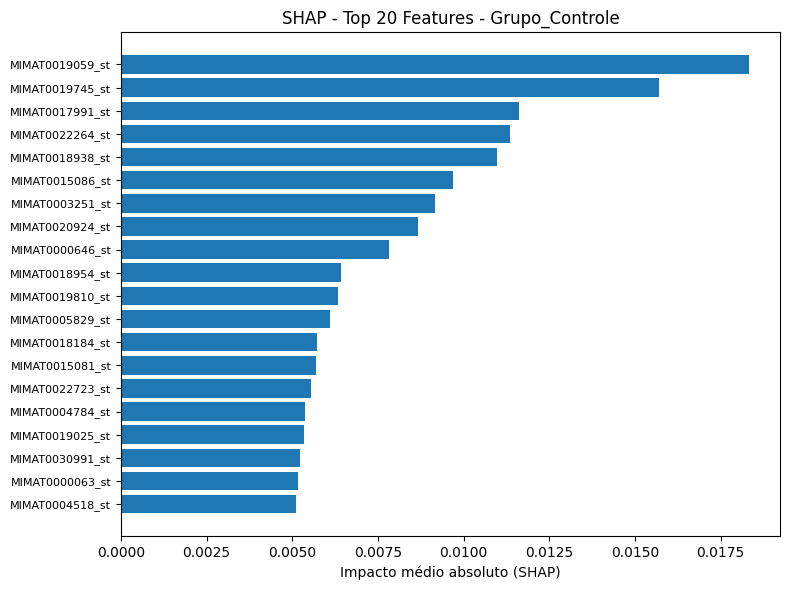

Figura salva: plots/SHAP_Top20_Grupo_PDAC.png


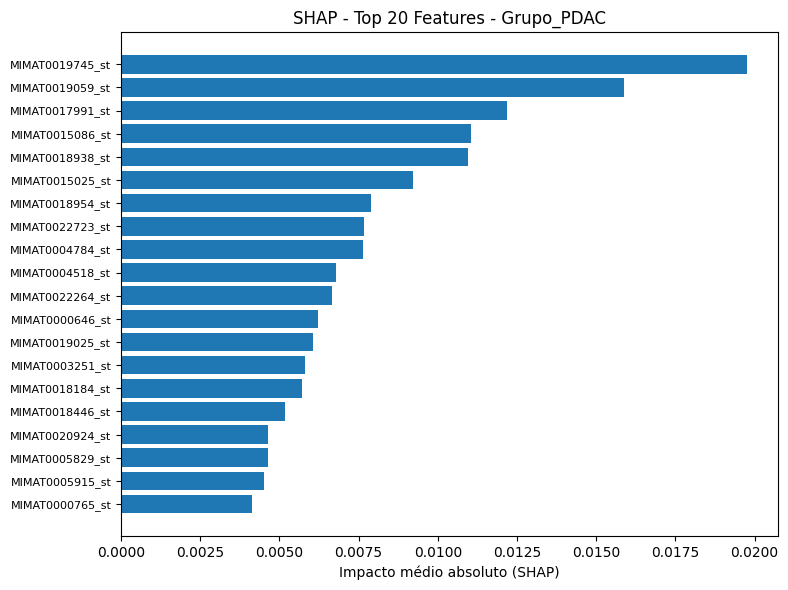

In [25]:
import matplotlib.pyplot as plt
import os

os.makedirs('plots', exist_ok=True)

top_k = 20

print("\n📊 Gerando gráficos SHAP Top 20...")

for classe, shap_df in shap_results.items():

    # pegar top k
    top = shap_df.head(top_k).iloc[::-1]

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.barh(top.index, top.values)

    ax.set_title(f'SHAP - Top {top_k} Features - {classe}')
    ax.set_xlabel('Impacto médio absoluto (SHAP)')
    ax.tick_params(axis='y', labelsize=8)

    plt.tight_layout()

    out_path = os.path.join(
        'plots',
        f'SHAP_Top{top_k}_{classe}.png'
    )

    fig.savefig(out_path, dpi=300, bbox_inches='tight')

    print(f"Figura salva: {out_path}")

    plt.show()
    plt.close(fig)